<a href="https://colab.research.google.com/github/23SCSE1010436/DDOS-Attack-Dection/blob/main/DDOS_attack_dectation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import plotly.express as px

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing

from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
import time

from sklearn import metrics


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import zipfile

# Path to the zipped file
zip_file_path = '/content/dataset_sdn.csv (2).zip'

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Assuming the CSV file inside the zip is named 'dataset_sdn.csv'
    # and we want to extract it to the current directory ('/content/')
    zip_ref.extract('dataset_sdn.csv', '/content/')

# Now read the extracted CSV file
data = pd.read_csv('/content/dataset_sdn.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.head().T

,0,1,2,3,4
dt,11425,11605,11425,11425,11425
switch,1,1,1,1,1
src,10.0.0.1,10.0.0.1,10.0.0.2,10.0.0.2,10.0.0.2
dst,10.0.0.8,10.0.0.8,10.0.0.8,10.0.0.8,10.0.0.8
pktcount,45304,126395,90333,90333,90333
bytecount,48294064,134737070,96294978,96294978,96294978
dur,100,280,200,200,200
dur_nsec,716000000,734000000,744000000,744000000,744000000
tot_dur,101000000000.0,281000000000.0,201000000000.0,201000000000.0,201000000000.0
flows,3,2,3,3,3


In [ ]:
data.shape

(104345, 23)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt           104345 non-null  int64  
 1   switch       104345 non-null  int64  
 2   src          104345 non-null  object 
 3   dst          104345 non-null  object 
 4   pktcount     104345 non-null  int64  
 5   bytecount    104345 non-null  int64  
 6   dur          104345 non-null  int64  
 7   dur_nsec     104345 non-null  int64  
 8   tot_dur      104345 non-null  float64
 9   flows        104345 non-null  int64  
 10  packetins    104345 non-null  int64  
 11  pktperflow   104345 non-null  int64  
 12  byteperflow  104345 non-null  int64  
 13  pktrate      104345 non-null  int64  
 14  Pairflow     104345 non-null  int64  
 15  Protocol     104345 non-null  object 
 16  port_no      104345 non-null  int64  
 17  tx_bytes     104345 non-null  int64  
 18  rx_bytes     104345 non-

label
0    63561
1    40784
Name: count, dtype: int64


<Axes: ylabel='count'>

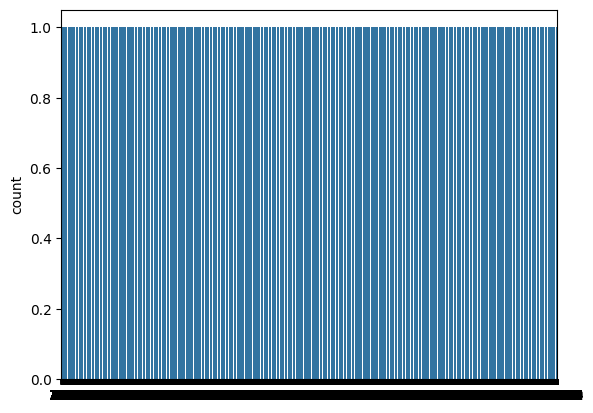

In [ ]:
import seaborn as sns

print(data.label.value_counts())
label_dict = dict(data.label.value_counts())
sns.countplot(data.label)

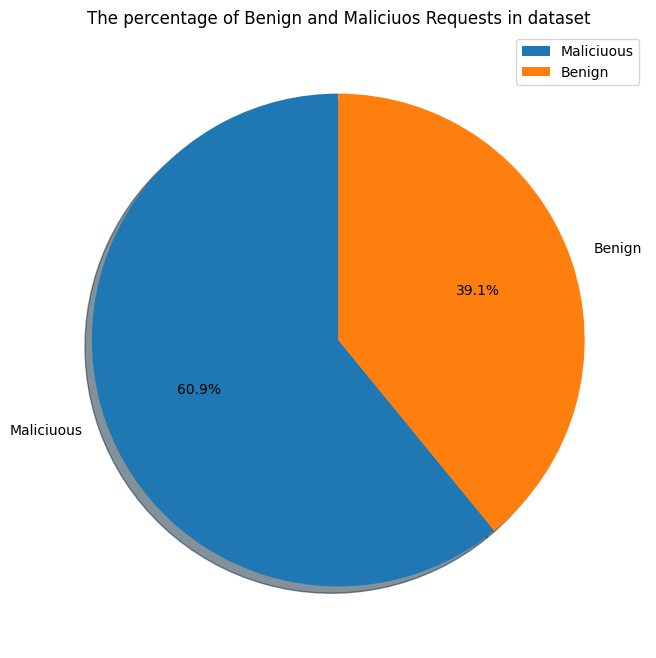

In [ ]:
import matplotlib.pyplot as plt

labels = ["Maliciuous",'Benign']
sizes = [dict(data.label.value_counts())[0], dict(data.label.value_counts())[1]]
plt.figure(figsize = (13,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.legend(["Maliciuous", "Benign"])
plt.title('The percentage of Benign and Maliciuos Requests in dataset')
plt.show()

In [ ]:
data.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,1.043450e+05,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,1.043450e+05,104345.000000,103839.000000,103839.000000,104345.000000
mean,17927.514169,4.214260,52860.954746,3.818660e+07,321.497398,4.613880e+08,3.218865e+11,5.654234,5200.383468,6381.715291,4.716150e+06,212.210676,0.600987,2.331094,9.325264e+07,9.328039e+07,998.899756,1003.811420,2007.578742,0.390857
std,11977.642655,1.956327,52023.241460,4.877748e+07,283.518232,2.770019e+08,2.834029e+11,2.950036,5257.001450,7404.777808,7.560116e+06,246.855123,0.489698,1.084333,1.519380e+08,1.330004e+08,2423.471618,2054.887034,3144.437173,0.487945
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7098.000000,3.000000,808.000000,7.957600e+04,127.000000,2.340000e+08,1.270000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.743000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11905.000000,4.000000,42828.000000,6.471930e+06,251.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8305.000000,5.521680e+05,276.000000,1.000000,2.000000,4.219610e+06,1.338339e+07,0.000000,0.000000,4.000000,0.000000
75%,29952.000000,5.000000,94796.000000,7.620354e+07,412.000000,7.030000e+08,4.130000e+11,7.000000,7462.000000,10017.000000,9.728112e+06,333.000000,1.000000,3.000000,1.356398e+08,1.439277e+08,251.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


Text(0.5, 1.0, 'Features which has NuLL values')

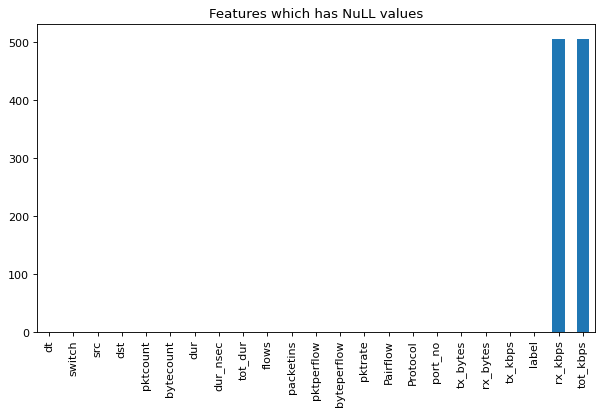

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5), dpi=80)
data[data.columns[data.isna().sum() >= 0]].isna().sum().sort_values().plot.bar()
plt.title("Features which has NuLL values")

In [ ]:
data.isnull().sum()

,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
tot_dur,0
flows,0


In [ ]:
data.isnull().sum()


,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
tot_dur,0
flows,0


In [ ]:
numeric_df = data.select_dtypes(include=['int64', 'float64'])
object_df = data.select_dtypes(include=['object'])
numeric_cols = numeric_df.columns
object_cols = object_df.columns
print('Numeric Columns: ')
print(numeric_cols, '\n')
print('Object Columns: ')
print(object_cols, '\n')
print('Number of Numeric Features: ', len(numeric_cols))
print('Number of Object Features: ', len(object_cols))

Numeric Columns: 
Index(['dt', 'switch', 'pktcount', 'bytecount', 'dur', 'dur_nsec', 'tot_dur',
       'flows', 'packetins', 'pktperflow', 'byteperflow', 'pktrate',
       'Pairflow', 'port_no', 'tx_bytes', 'rx_bytes', 'tx_kbps', 'rx_kbps',
       'tot_kbps', 'label'],
      dtype='object') 

Object Columns: 
Index(['src', 'dst', 'Protocol'], dtype='object') 

Number of Numeric Features:  20
Number of Object Features:  3


In [ ]:
object_df.head()

,src,dst,Protocol
0,10.0.0.1,10.0.0.8,UDP
1,10.0.0.1,10.0.0.8,UDP
2,10.0.0.2,10.0.0.8,UDP
3,10.0.0.2,10.0.0.8,UDP
4,10.0.0.2,10.0.0.8,UDP


Text(0.5, 1.0, 'Number of all reqests')

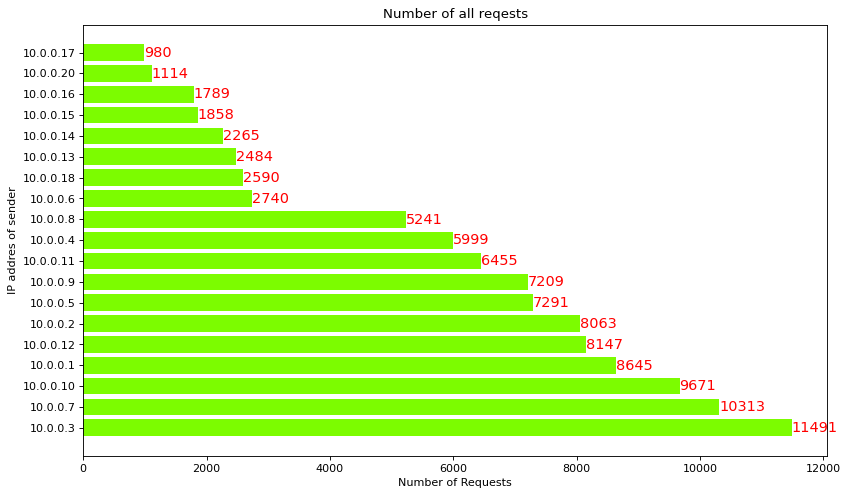

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7), dpi=80)
plt.barh(list(dict(data.src.value_counts()).keys()), dict(data.src.value_counts()).values(), color='lawngreen')

for idx, val in enumerate(dict(data.src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='r', size = 13)

plt.xlabel('Number of Requests')
plt.ylabel('IP addres of sender')
plt.title('Number of all reqests')

Text(0.5, 1.0, 'Number of Attack requests')

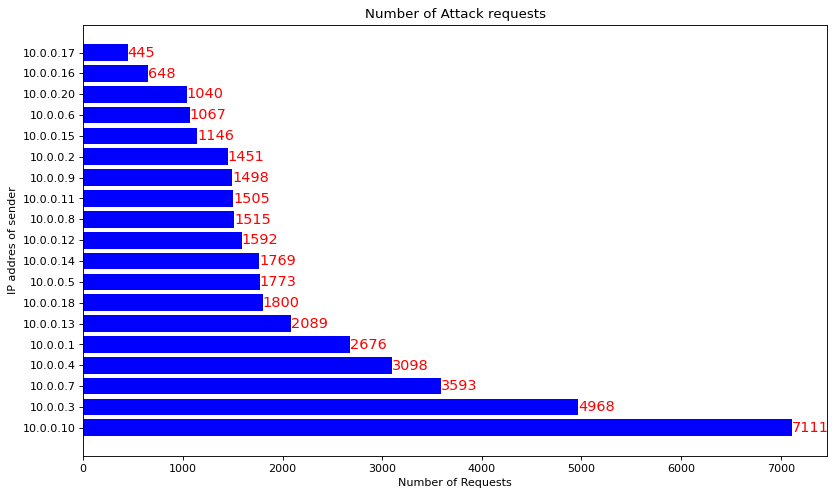

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7), dpi=80)
plt.barh(list(dict(data[data.label == 1].src.value_counts()).keys()), dict(data[data.label == 1].src.value_counts()).values(), color='blue')

for idx, val in enumerate(dict(data[data.label == 1].src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='r', size = 13)

plt.xlabel('Number of Requests')
plt.ylabel('IP addres of sender')
plt.title('Number of Attack requests')

Text(0.5, 1.0, 'Number of requests from different IP adress')

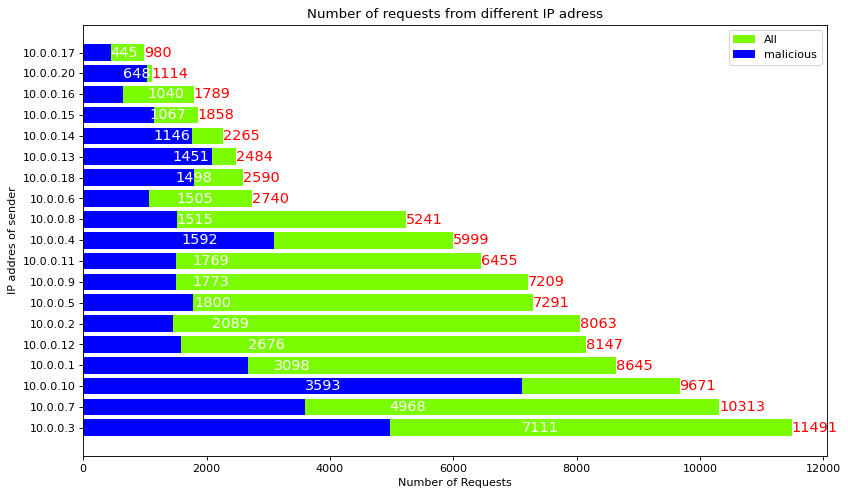

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

plt.figure(figsize=(12, 7), dpi=80)
plt.barh(list(dict(data.src.value_counts()).keys()), dict(data.src.value_counts()).values(), color='lawngreen')
plt.barh(list(dict(data[data.label == 1].src.value_counts()).keys()), dict(data[data.label == 1].src.value_counts()).values(), color='blue')

for idx, val in enumerate(dict(data.src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='r', size = 13)

for idx, val in enumerate(dict(data[data.label == 1].src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='w', size = 13)


plt.xlabel('Number of Requests')
plt.ylabel('IP addres of sender')
plt.legend(['All','malicious'])
plt.title('Number of requests from different IP adress')

Text(0.5, 1.0, 'The number of requests from different protocols')

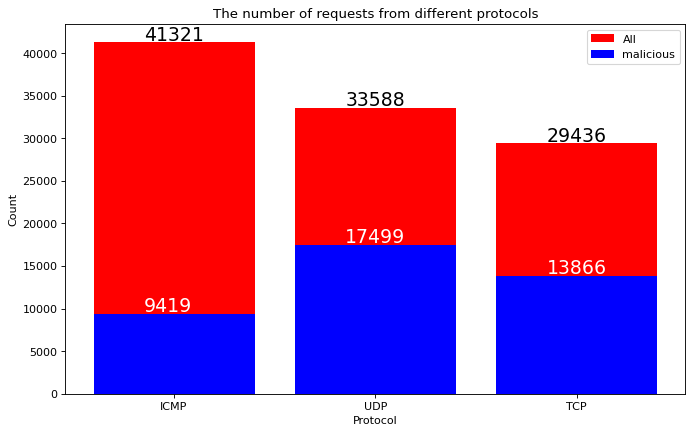

In [ ]:
figure(figsize=(10, 6), dpi=80)
plt.bar(list(dict(data.Protocol.value_counts()).keys()), dict(data.Protocol.value_counts()).values(), color='r')
plt.bar(list(dict(data[data.label == 1].Protocol.value_counts()).keys()), dict(data[data.label == 1].Protocol.value_counts()).values(), color='b')

plt.text(x = 0 - 0.15, y = 41321 + 200, s = str(41321), color='black', size=17)
plt.text(x = 1 - 0.15, y = 33588 + 200, s = str(33588), color='black', size=17)
plt.text(x = 2 - 0.15, y = 29436 + 200, s = str(29436), color='black', size=17)

plt.text(x = 0 - 0.15, y = 9419 + 200, s = str(9419), color='w', size=17)
plt.text(x = 1 - 0.15, y = 17499 + 200, s = str(17499), color='w', size=17)
plt.text(x = 2 - 0.15, y = 13866 + 200, s = str(13866), color='w', size=17)

plt.xlabel('Protocol')
plt.ylabel('Count')
plt.legend(['All', 'malicious'])
plt.title('The number of requests from different protocols')

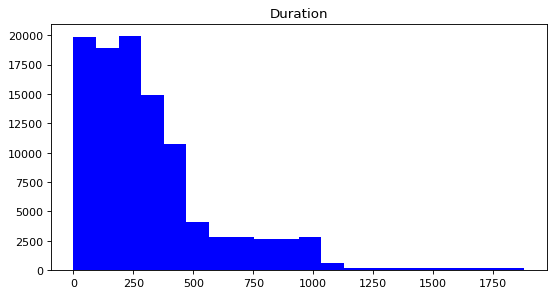

In [ ]:
figure(figsize=(8, 4), dpi=80)
plt.hist(data.dur, bins=20, color='b')
plt.title('Duration')
plt.show()

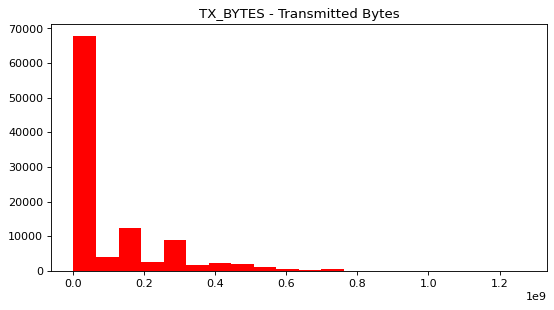

In [ ]:
figure(figsize=(8, 4), dpi=80)
plt.hist(data.tx_bytes, bins=20, color='r')
plt.title('TX_BYTES - Transmitted Bytes')
plt.show()

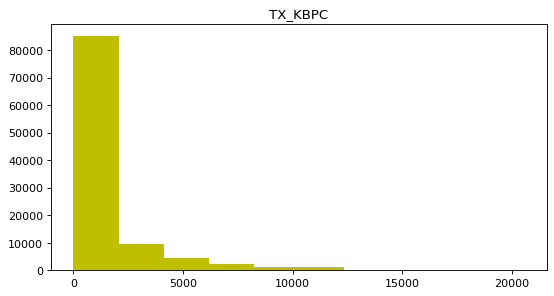

In [ ]:
figure(figsize=(8, 4), dpi=80)
plt.hist(data.tx_kbps, bins=10, color='y')
plt.title('TX_KBPC')
plt.show()

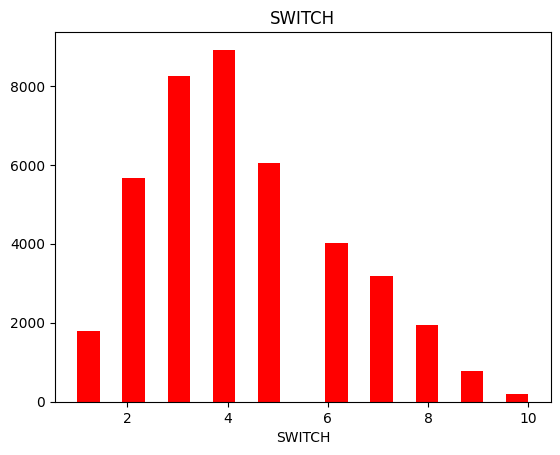

In [ ]:
plt.hist(data[data['label'] == 1].switch, bins=20, color='r')
plt.title('SWITCH')
plt.xlabel('SWITCH')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import pandas as pd
import zipfile

# Path to the zipped file
zip_file_path = '/content/dataset_sdn.csv (2).zip'

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Assuming the CSV file inside the zip is named 'dataset_sdn.csv'
    # and we want to extract it to the current directory ('/content/')
    zip_ref.extract('dataset_sdn.csv', '/content/')

# Now read the extracted CSV file
data = pd.read_csv('/content/dataset_sdn.csv')

# Fix negative values
data['pktperflow'] = data['pktperflow'].apply(lambda x: max(x, 0))
data['byteperflow'] = data['byteperflow'].apply(lambda x: max(x, 0))

# Fill missing values
data['rx_kbps'] = data['rx_kbps'].fillna(data['rx_kbps'].mean())
data['tot_kbps'] = data['tot_kbps'].fillna(data['tot_kbps'].mean())

# Encoding
data_encoded = pd.get_dummies(data, columns=['src', 'dst', 'Protocol'], drop_first=True)

# Features & target
X = data_encoded.drop('label', axis=1)
y = data_encoded['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Metrics (safe for multi-class)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19112
           1       1.00      1.00      1.00     12192

    accuracy                           1.00     31304
   macro avg       1.00      1.00      1.00     31304
weighted avg       1.00      1.00      1.00     31304


Confusion Matrix:
 [[19112     0]
 [    0 12192]]


In [ ]:
# This script is based on official RAPIDS Colab installation instructions
# It ensures the correct CUDA version is used and installs the RAPIDS libraries.
import sys, os, shutil

# Remove pre-installed CPU CUDA to avoid conflicts
# This step is often necessary in Colab to ensure GPU CUDA is correctly used
if os.path.exists('/opt/conda/envs/rapids/lib/python3.10/site-packages/cuda_runtime.py'):
    print('Removing pre-installed CPU CUDA...')
    shutil.rmtree('/opt/conda/envs/rapids')
    shutil.rmtree('/opt/conda/pkgs')

# Install RAPIDS (cuml and cupy included) for a specific CUDA version
# We'll use a common Colab setup for CUDA 11.8 and RAPIDS 23.10
# This typically involves cloning a helper script and executing it.
!git clone https://github.com/rapidsai/rapids-colab.git
!cd rapids-colab && bash ./install_rapids.sh 23.10 cuda-11.8

# Set up environment variables required for RAPIDS libraries
os.environ['NUMBAPRO_NVVM'] = '/usr/local/cuda/nvvm/lib64/libnvvm.so'
os.environ['NUMBAPRO_LIBDEVICE'] = '/usr/local/cuda/nvvm/libdevice/libdevice.10.bc'
os.environ['CONDA_PREFIX'] = '/usr/local/lib/python3.10/dist-packages'
sys.path.append('/usr/local/lib/python3.10/dist-packages/rapids')

print("RAPIDS Libraries (cuml, cupy, etc.) installed successfully!")
print("Please restart the runtime (Runtime -> Restart runtime) for changes to take effect.")

Cloning into 'rapids-colab'...
fatal: could not read Username for 'https://github.com': No such device or address
/bin/bash: line 1: cd: rapids-colab: No such file or directory
RAPIDS Libraries (cuml, cupy, etc.) installed successfully!
Please restart the runtime (Runtime -> Restart runtime) for changes to take effect.
